In [4]:
using NLsolve, ForwardDiff, Plots, TaylorSeries, SpecialFunctions, LaTeXStrings
 
function  weights(N,α)
     z = Taylor1(N)   
        poly = (2*(1-z)/(1+z))^α;
    return poly.coeffs;         
end

weights (generic function with 1 method)

In [5]:
function IntegratorBDF(q₀ ,  p₀ , N ,  T, α)

ω = weights(N,α); Δt = T/N;  ts = (0:N)*Δt;

f(t) = t^3  + 6 * t + (3.2 / gamma(0.5)) * t^2.5; # exact = t^3 for α=0.5

    
F =  f.(ts .+Δt/2);       

    
L(k) = (q,v) -> (1/2) * v^2 - (1/2) * q^2 + q * F[k];

Ld(k) = ((x , y),) -> Δt * L(k)((y+x)/2 , (y-x) / Δt)

DL(i,k) = u -> ForwardDiff.gradient( Ld(k) , u )[i]
    

q = [];   
 
DEL0 = u -> p₀ + DL(1,1)([q₀ ,u]) - 0.5 * ω[1] * Δt^(1-α) *  (u+q₀)/2 ;

init_geuss =  [q₀ + Δt *  p₀];     
    
r = nlsolve(u -> DEL0(u[1]), init_geuss; autodiff = :forward,ftol=1e-14)
    
append!(q,q₀, r.zero); 


for k in 3:N+1  
        
Qnew = u -> (q + vcat(q[2:end],u))/2;
Qold =  (q[1:end-1]+q[2:end])/2  

        
DEL = (q,u) -> DL(2,k-2)([q[end-1],q[end]]) + DL(1,k-1)([q[end] ,u])- 0.5*Δt^(1-α)* reverse(ω[1:k-2])' * Qold - 0.5* Δt^(1-α)*reverse(ω[1:k-1])' * Qnew(u); 
        
init_geuss = [q[end] + Δt *  p₀];
        
r = nlsolve(u -> DEL(q,u[1]), init_geuss; autodiff = :forward,ftol=1e-14)
#all_converged(res) =  r.f_converged
#@show all_converged(r)
append!(q, r.zero); 
                    
end

    return q;
    
end
    

IntegratorBDF (generic function with 1 method)

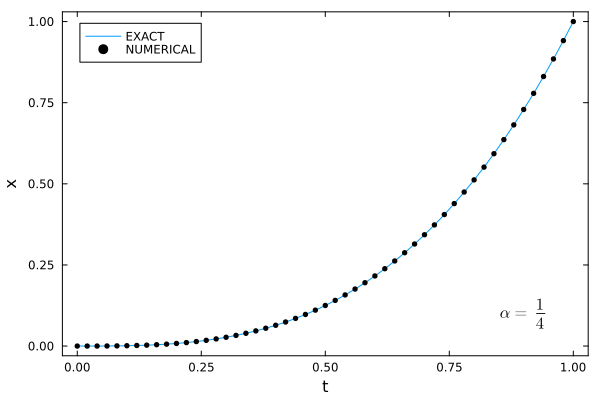

In [6]:
q₀ = 0.0 ;  p₀ = 0.0 ; α = 0.5 ; N = 50 ; T = 1; ts = (0:N)*T/N;

exact(t)=t^3;

q  = IntegratorBDF(q₀ , p₀ , N , T,α)

plt1=plot(ts, exact.(ts),label="EXACT")

plt1=scatter!(ts, q,m=:circle,ms=3,mc=:black,label="NUMERICAL")
annotate!(plt1,[0.9], [0.1], text(L"\alpha=\frac{1}{4}",11))
plot!(plt1,xlabel="t", ylabel="x",grid=false,framestyle=:box)

In [9]:
using LaTeXStrings
Ns=2 .^(2:10)

T = 1;

m = length(Ns);

err = zeros(m)

for i in 1:m

N = Ns[i]; ts = (0:N)*T/N;
    
q  = IntegratorBDF(q₀ , p₀ , N , T,α)

err[i] = norm(q .- exact.(ts), Inf)
end    

h = T ./Ns;

f(x)=x^2;


plt2=plot(h , err,label="MIDPOINT" , m =:sq,grid=false,framestyle=:box,xlabel="log₁₀(h)", ylabel="log₁₀(xErr)")
plot!(plt2,h , f.(h) , label=L"O(h^{2})")
plot!(plt2,xscale=:log10, yscale=:log10, legend=:topleft)
annotate!(plt2,[1e-1], [0.5e-6], text(L"\alpha=\frac{1}{4}",11))

#plot(plt1,plt2,layout=(1,2),legend=:topright)

plot(plt2,legend=:topright)


#savefig("MIDPOINT_nonInt_Errors05.pdf")


savefig("MIDPOINT_Errors05.pdf")

"/home/hariz/Desktop/RKCQ_1206/MIDPOINT_Errors05.pdf"